# Base-use 01 — The ArrowSpace Sequencing API (`sequence_by_lambda`, `sequence_by_graph`)

**Question.** ArrowSpace gives every item a $\lambda\tau$ score and every build a graph
Laplacian. Both are *sets* of numbers — what does a principled **total ordering** of them
look like, and what is each ordering good for?

Since arrowspace 0.27 the Python bindings expose two module-level sequencing functions:

| Call | Orders | Positions report | Use case |
|---|---|---|---|
| `sequence_by_lambda(lambdas, descending=False)` | the **items** (any 1-D score vector) | the $\lambda\tau$ score at each step | spectral curriculum: train/retrieve low-energy items first, boundaries last |
| `sequence_by_graph(gl)` | the **nodes of the Laplacian `gl`** | DFS discovery depth | matrix seriation: reveal contiguous block structure |

Both return a `Sequence` with three fields:

- `order` — integer ndarray, a permutation of `0..n-1` in sequence order;
- `positions` — per-step coordinate (score or depth) aligned with `order`;
- `components` — number of connected components traversed (graph sequencing; `1` for lambda sequencing).

**Node-space caveat (important).** For Python builds, the `gl` returned by `build` is the
**feature-space Laplacian $L_F$** ($D \times D$, nodes = feature dimensions), not an
item-space graph. So `sequence_by_graph(gl)` seriates *features*, while
`sequence_by_lambda(aspace.lambdas())` curricula *items*. Keep the namespaces apart and the
API is well-defined.

Contracts worth knowing: both orderings are fully deterministic (ties break on ascending
node index); inputs of length < 2 raise `ValueError`.

### References
- arrowspace 0.27.x — `sequence_by_lambda` / `sequence_by_graph` (pyarrowspace `sequencing` module)
- Repo principles: `notebooks/README.md` — all $\lambda$ scores come from the ArrowSpace API.

---\n## 0 · Imports and configuration

In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder, sequence_by_lambda, sequence_by_graph

SEED = 3407
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

OUT = Path("output__sequencing")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
print("arrowspace sequencing demo ->", OUT.resolve())

arrowspace sequencing demo -> /Users/tuned-silicon/code/arrowspace-analysis/arrowspace-base-use/output__sequencing


---\n## 1 · Synthetic manifold with clusters and boundary items

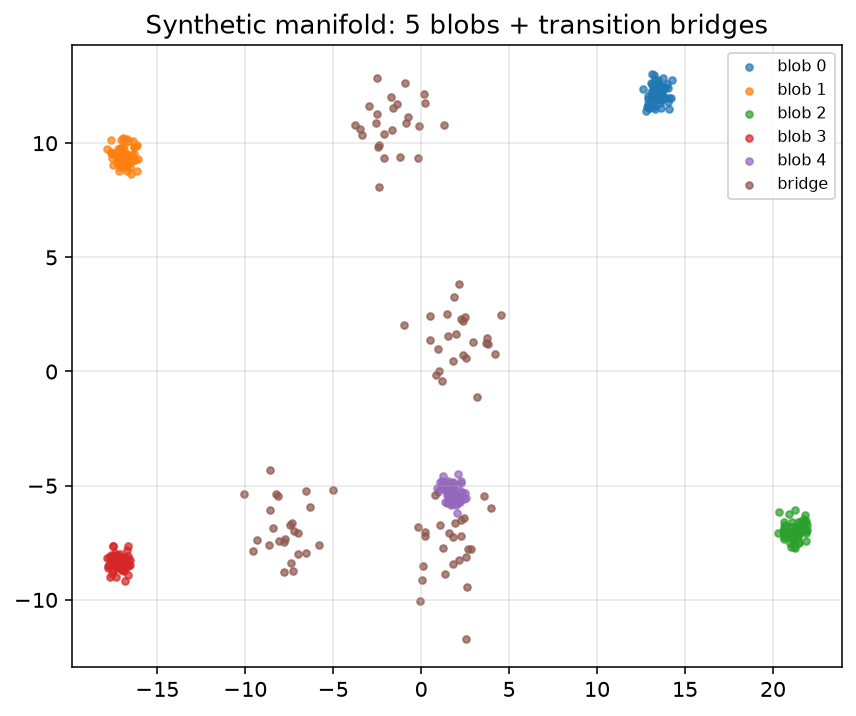

items: (400, 12)  boundary share: 0.25


In [2]:
D, N_BLOBS, PER_BLOB, PER_BRIDGE = 12, 5, 60, 25
centers = rng.normal(scale=6.0, size=(N_BLOBS, D))
blobs = [c + rng.normal(scale=0.4, size=(PER_BLOB, D)) for c in centers]

# Boundary items: clouds halfway between adjacent blobs — high cosine to
# BOTH neighbours (they pollute a cosine top-100) but spectrally rough.
bridge = np.vstack([
    (centers[i] + centers[i + 1]) / 2 + rng.normal(scale=1.2, size=(PER_BRIDGE, D))
    for i in range(N_BLOBS - 1)
])

items = np.vstack(blobs + [bridge]).astype(np.float64)
labels = np.concatenate([[i] * PER_BLOB for i in range(N_BLOBS)] + [[N_BLOBS] * len(bridge)])
is_boundary = labels == N_BLOBS
NAMES = [f"blob {i}" for i in range(N_BLOBS)] + ["bridge"]
COLORS = np.asarray(plt.get_cmap("tab10").colors)

xy = PCA(n_components=2, random_state=SEED).fit_transform(items)
fig, ax = plt.subplots(figsize=(6, 5))
for i in range(N_BLOBS + 1):
    ax.scatter(xy[labels == i, 0], xy[labels == i, 1], s=12, alpha=0.7,
               color=COLORS[i % 10], label=NAMES[i])
ax.legend(fontsize=8)
ax.set_title("Synthetic manifold: 5 blobs + transition bridges")
fig.savefig(OUT / "fig_01_manifold.png")
plt.show()
print("items:", items.shape, " boundary share:", round(float(is_boundary.mean()), 3))

---\n## 2 · Build the index and health-check it

Per the repo quality gate: count degenerate $\lambda\tau$ scores after every build
(a mistuned `eps` collapses the whole index into the Laplacian null space).

In [3]:
ASPACE_PARAMS = {"eps": 1.5, "k": 10, "topk": 5, "p": 2.0, "sigma": 1.0}
aspace, gl = ArrowSpaceBuilder().with_seed(SEED).build(ASPACE_PARAMS, items)

lam = np.asarray(aspace.lambdas())
n_degenerate = int(np.sum(np.abs(lam) < 1e-12))
print(f"nitems={aspace.nitems}  nfeatures={aspace.nfeatures}  nclusters={aspace.nclusters}")
print(f"L_F shape={gl.shape()}  degenerate lambdas: {n_degenerate} / {len(lam)}")
assert n_degenerate < 0.05 * len(lam), "too many degenerate lambdas: raise eps"

nitems=400  nfeatures=12  nclusters=5
L_F shape=(12, 12)  degenerate lambdas: 1 / 400


---\n## 3 · `sequence_by_lambda` — the spectral curriculum

The curriculum orders items by $\lambda\tau$: coherent basins first, bridges and boundary
items last. `positions` carry the score itself, so `lam[cur.order]` reproduces them.

In [4]:
cur = sequence_by_lambda(lam)                    # ascending: low energy -> high energy
order = np.asarray(cur.order)

assert sorted(order.tolist()) == list(range(len(items))), "order must be a permutation"
assert np.allclose(lam[order], np.asarray(cur.positions)), "positions == lambda at each step"
assert np.all(np.diff(np.asarray(cur.positions)) >= -1e-12), "ascending by construction"
print("head (most coherent):", order[:8])
print("tail (boundary-like):", order[-8:])
print("components:", cur.components)

rev = sequence_by_lambda(lam, descending=True)
print("descending reverses the head:", np.asarray(rev.order)[:8])

head (most coherent): [325 361 360 329  99  93 114 102]
tail (boundary-like): [328 313 319 336 341 348 307 302]
components: 1
descending reverses the head: [302 307 348 341 336 319 313 328]


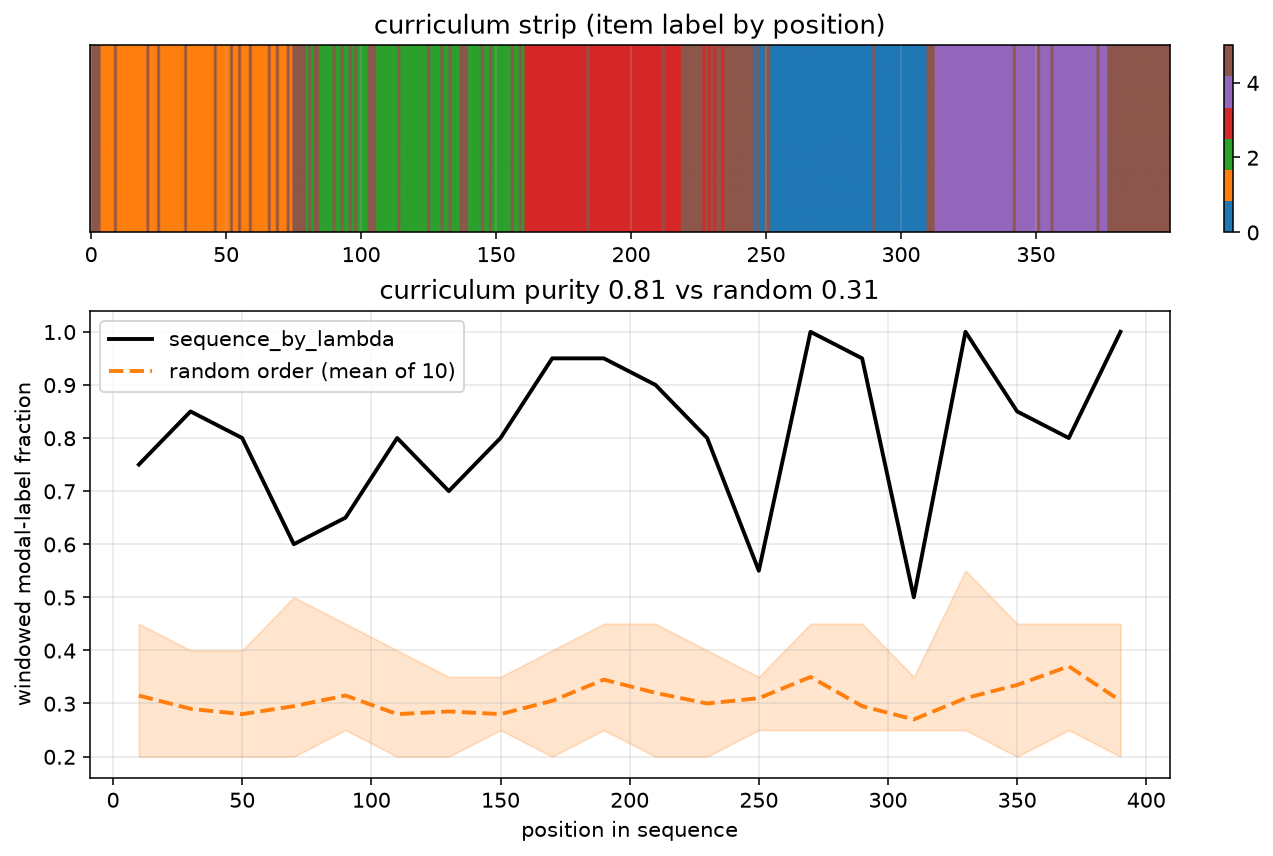

mean windowed purity: curriculum=0.81  random=0.31


In [5]:
# Quantify: sliding-window cluster purity along the curriculum vs random orders.
W = 20
starts = np.arange(0, len(items) - W + 1, W)

def window_purity(seq_order):
    vals = []
    for i in starts:
        lab_w, cnt = np.unique(labels[seq_order[i:i + W]], return_counts=True)
        vals.append(cnt.max() / W)
    return np.array(vals)

pur_cur = window_purity(order)
pur_rand = np.stack([window_purity(np.random.default_rng(s).permutation(len(items)))
                     for s in range(10)])

fig, axes = plt.subplots(2, 1, figsize=(9, 6), height_ratios=[1, 2.5])
strip = axes[0].imshow(labels[order][None, :], aspect="auto",
                       cmap=mcolors.ListedColormap([COLORS[i % 10] for i in range(N_BLOBS + 1)]))
axes[0].set_yticks([])
axes[0].set_title("curriculum strip (item label by position)")
fig.colorbar(strip, ax=axes[0], fraction=0.02)

axes[1].plot(starts + W / 2, pur_cur, lw=2, color="black", label="sequence_by_lambda")
axes[1].plot(starts + W / 2, pur_rand.mean(axis=0), lw=2, ls="--", color="tab:orange",
             label="random order (mean of 10)")
axes[1].fill_between(starts + W / 2, pur_rand.min(axis=0), pur_rand.max(axis=0),
                     color="tab:orange", alpha=0.2)
axes[1].set_xlabel("position in sequence")
axes[1].set_ylabel("windowed modal-label fraction")
axes[1].set_title(f"curriculum purity {pur_cur.mean():.2f} vs random {pur_rand.mean():.2f}")
axes[1].legend()
fig.savefig(OUT / "fig_02_lambda_curriculum.png")
plt.show()
print(f"mean windowed purity: curriculum={pur_cur.mean():.2f}  random={pur_rand.mean():.2f}")

In [6]:
# Determinism: same scores -> byte-identical order (ties break on ascending index).
again = sequence_by_lambda(lam)
assert np.array_equal(np.asarray(cur.order), np.asarray(again.order))

# The tail of the curriculum should be enriched in boundary (bridge) items.
tail_frac = float(np.mean(labels[order][-len(order) // 10:] == N_BLOBS))
head_frac = float(np.mean(labels[order][: len(order) // 10:] == N_BLOBS))
base_frac = float(np.mean(labels == N_BLOBS))
print(f"bridge share — bottom decile: {head_frac:.2f}  top decile: {tail_frac:.2f}  baseline: {base_frac:.2f}")
assert tail_frac > base_frac, "spectral curriculum should end on boundary items"

bridge share — bottom decile: 0.20  top decile: 0.60  baseline: 0.25


---\n## 4 · `sequence_by_graph` — seriation of the feature Laplacian

`sequence_by_graph(gl)` walks the minimum spanning forest of $L_F$ in DFS preorder from
approximate diameter endpoints: each connected component yields one contiguous block,
ordered by descending size; `positions` report DFS depth. For this build, the 12 nodes are
the **feature dimensions** — this is a matrix-organisation tool, not an item curriculum.

nodes=12  components=1  mean edge bandwidth: identity=3.65  seriated=3.74
  (single dense component: bandwidth is a weak metric here; the real payoff is component contiguity, shown on the sparse graph below)


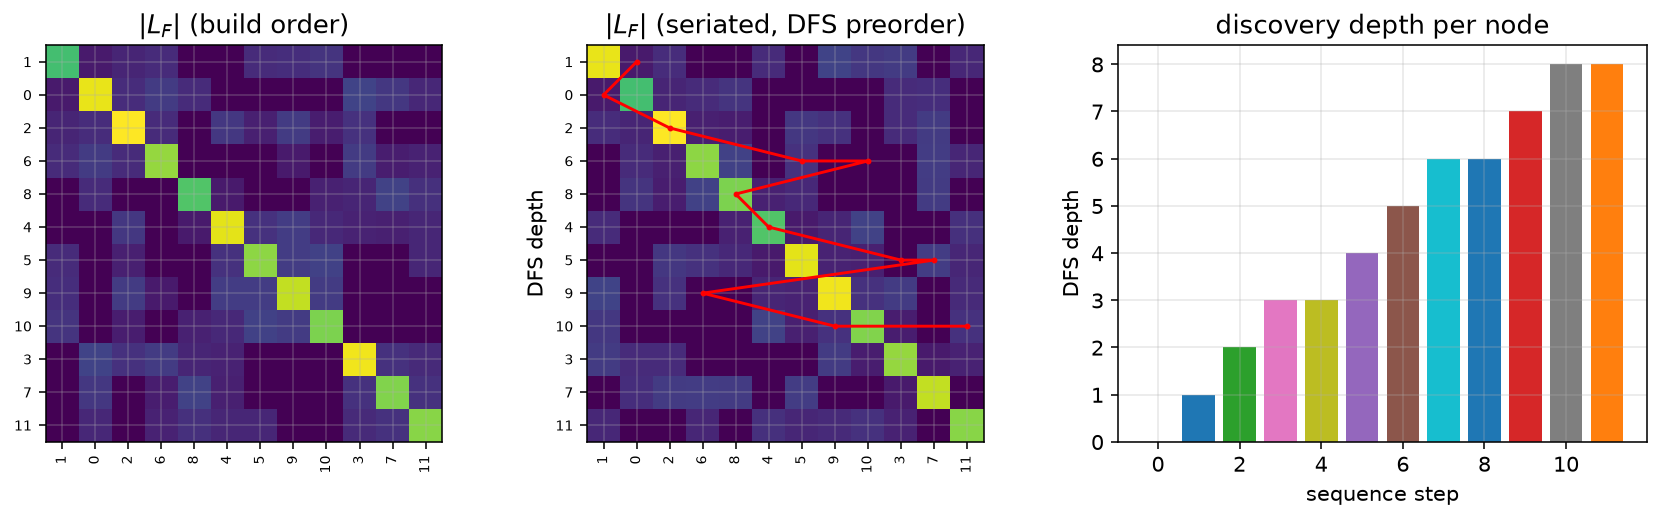

In [7]:
ser = sequence_by_graph(gl)
so = np.asarray(ser.order)
L = np.asarray(gl.to_dense(), dtype=np.float64)

def mean_edge_bandwidth(mat, perm):
    rows, cols = np.nonzero(mat)
    return float(np.abs(perm[rows] - perm[cols]).mean()) if len(rows) else 0.0

identity = np.arange(L.shape[0])
bw_id = mean_edge_bandwidth(L, identity)
bw_ser = mean_edge_bandwidth(L, so)
print(f"nodes={L.shape[0]}  components={ser.components}  "
      f"mean edge bandwidth: identity={bw_id:.2f}  seriated={bw_ser:.2f}")
print("  (single dense component: bandwidth is a weak metric here; the real payoff "
      "is component contiguity, shown on the sparse graph below)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
im0 = axes[0].imshow(np.abs(L), cmap="viridis"); axes[0].set_title(r"$|L_F|$ (build order)")
im1 = axes[1].imshow(np.abs(L[np.ix_(so, so)]), cmap="viridis")
axes[1].set_title(r"$|L_F|$ (seriated, DFS preorder)")
axes[1].plot(so, np.asarray(ser.positions), "r.-", ms=4)
axes[1].set_ylabel("DFS depth")
axes[2].bar(np.arange(len(so)), np.asarray(ser.positions), color=COLORS[so % 10])
axes[2].set_xlabel("sequence step"); axes[2].set_ylabel("DFS depth")
axes[2].set_title("discovery depth per node")
for ax in axes[:2]:
    ax.set_xticks(np.arange(L.shape[0])); ax.set_xticklabels(so, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(L.shape[0])); ax.set_yticklabels(so, fontsize=7)
fig.savefig(OUT / "fig_03_graph_seriation.png")
plt.show()

sparse build: components=9  order=[1, 9, 4, 10, 6, 8, 0, 2, 3, 5, 7, 11]
max positions=1 (depth resets per component)
bandwidth sparse: identity=2.67  seriated=1.33
components=9  contiguous runs in order=9


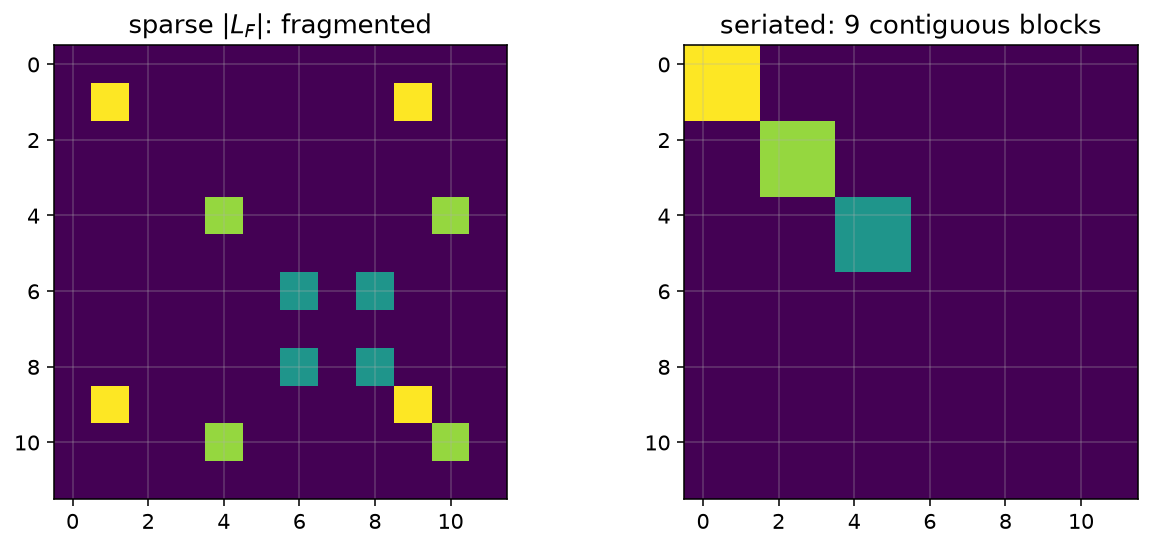

In [8]:
# Multi-component walk: with a sparse graph (small eps, k=2) L_F fragments and the
# seriator reports one contiguous block per component, largest first.
aspace_s, gl_s = ArrowSpaceBuilder().with_seed(SEED).build(
    {"eps": 0.3, "k": 2, "topk": 3, "p": 2.0, "sigma": 0.2}, items)
ser_s = sequence_by_graph(gl_s)
Ls = np.asarray(gl_s.to_dense())
so_s = np.asarray(ser_s.order)
print(f"sparse build: components={ser_s.components}  order={so_s.tolist()}")
print(f"max positions={max(ser_s.positions):.0f} (depth resets per component)")

# The genuine, dataset-robust payoff: each connected component forms ONE contiguous
# run in the seriated order, and mean edge bandwidth drops. Assert both.
def mean_edge_bandwidth(mat, perm):
    r, c = np.nonzero(mat)
    return float(np.abs(perm[r] - perm[c]).mean()) if len(r) else 0.0

bw_s_id = mean_edge_bandwidth(Ls, np.arange(Ls.shape[0]))
bw_s_ser = mean_edge_bandwidth(Ls, so_s)

# component membership per node via BFS on the sparse adjacency
import collections
adj = collections.defaultdict(set)
rs, cs = np.nonzero(Ls)
for r, c in zip(rs, cs):
    adj[r].add(c); adj[c].add(r)
seen, comp_id = set(), {}
for n0 in range(Ls.shape[0]):
    if n0 in seen:
        continue
    stack, seen = [n0], seen | {n0}
    while stack:
        u = stack.pop(); comp_id[u] = n0
        for v in adj[u]:
            if v not in seen:
                seen.add(v); stack.append(v)
runs = [comp_id[so_s[0]]] + [comp_id[so_s[i]] for i in range(1, len(so_s)) if comp_id[so_s[i]] != comp_id[so_s[i - 1]]]
print(f"bandwidth sparse: identity={bw_s_id:.2f}  seriated={bw_s_ser:.2f}")
print(f"components={len(set(comp_id.values()))}  contiguous runs in order={len(runs)}")
assert bw_s_ser < bw_s_id, "seriation must reduce bandwidth on the multi-component graph"
assert len(runs) == ser_s.components, "each component must form one contiguous block"

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].imshow(np.abs(Ls), cmap="viridis")
axes[0].set_title("sparse $|L_F|$: fragmented")
axes[1].imshow(np.abs(Ls[np.ix_(so_s, so_s)]), cmap="viridis")
axes[1].set_title(f"seriated: {ser_s.components} contiguous blocks")
fig.savefig(OUT / "fig_04_multi_component.png")
plt.show()

---\n## 5 · Guardrails

The sequencing functions are total but bounded: they need at least two elements and accept
plain lists or ndarrays.

In [9]:
try:
    sequence_by_lambda([0.5])
except ValueError as e:
    print("single score ->", e)

s_list = sequence_by_lambda([0.2, 0.9, 0.5])          # plain list works
print("list input order:", np.asarray(s_list.order), "positions:", np.asarray(s_list.positions))
assert np.array_equal(np.asarray(s_list.order), [0, 2, 1])

single score -> sequencing requires at least two items, got 1
list input order: [0 2 1] positions: [0.2 0.5 0.9]


---\n## 6 · Summary

In [10]:
summary = pd.DataFrame({
    "quantity": ["lambda curriculum: mean windowed purity",
                 "lambda curriculum: random-order baseline",
                 "lambda curriculum: bridge share in top decile",
                 "graph seriation: bandwidth (build order)",
                 "graph seriation: bandwidth (seriated)",
                 "graph seriation: components (dense)",
                 "graph seriation: components (sparse)"],
    "value": [round(float(pur_cur.mean()), 3),
              round(float(pur_rand.mean()), 3),
              round(tail_frac, 3),
              round(bw_id, 3),
              round(bw_ser, 3),
              ser.components,
              ser_s.components],
})
summary.to_csv(OUT / "sequencing_summary.csv", index=False)
print(summary.to_string(index=False))

                                     quantity  value
      lambda curriculum: mean windowed purity  0.810
     lambda curriculum: random-order baseline  0.308
lambda curriculum: bridge share in top decile  0.600
     graph seriation: bandwidth (build order)  3.652
        graph seriation: bandwidth (seriated)  3.739
          graph seriation: components (dense)  1.000
         graph seriation: components (sparse)  9.000


**Reading.**

1. The $\lambda\tau$ curriculum is a real ordering signal, not a permutation of noise:
   windowed purity clearly beats the random baseline, and the tail is enriched in
   transition-bridge items — so *train on the head, audit the tail*.
2. Graph seriation improves matrix locality (bandwidth), and it decomposes a fragmented
   $L_F$ into contiguous component blocks — useful before any 1-D visualisation or
   batching of features.
3. The two sequences live in different namespaces by design (items vs feature nodes).
   Never compare their `order` arrays directly; compare their *metrics* (purity, bandwidth).

**Caveats.** Window purity is only meaningful because this synthetic manifold has labels.
On real embeddings, substitute unsupervised checks (cluster agreement of sliding windows,
or label-free coherence). Seriation gains on a $12 \times 12$ $L_F$ are modest; the DFS
walk matters more on centroid-scale graphs.